## Actividad Individual 2 - EDA básico
---

## Visitas a Estaciones Saludables de la Ciudad de Buenos Aires

Análisis exploratorio de datos (EDA) básico sobre el dataset de
**visitas a las Estaciones Saludables** de la Ciudad Autónoma de Buenos Aires.

Las Estaciones Saludables son puntos fijos ubicados en distintos barrios de la Ciudad donde
se ofrecen controles de salud gratuitos (peso, talla, presión arterial, glucemia, etc.) y
actividades de promoción de hábitos saludables. El dataset contiene la cantidad de personas
que visitaron estas estaciones, agrupadas por año, sexo, grupo etario y lugar de residencia.

Fuente: [Portal de Datos Abiertos de la Ciudad de Buenos Aires - Visitas a Estaciones Saludables](https://data.buenosaires.gob.ar/dataset/visitas-estaciones-saludables/resource/5ff36682-e501-49d0-96f9-0cfd60893333)

Resumen de variables:
* `anio` (variable categórica): año de la visita (2013 a 2016)
* `sexo` (variable categórica): sexo de la persona (`m` = mujer, `v` = varón)
* `cantidad_personas` (variable numérica): cantidad de personas que realizaron la visita en esa combinación de año, sexo, grupo etario y lugar de residencia
* `grupo_edad` (variable categórica): rango etario de la persona (en tramos de 10 años, más la categoría `Ignorado`)
* `lugar_residencia` (variable categórica): lugar de residencia de la persona (Ciudad de Buenos Aires, Otros fuera de CABA o `Ignorado`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

In [2]:
visitas = pd.read_csv('visitas_estaciones_saludables.csv')

---
## EDA (Exploratory Data Analysis) - Visitas a Estaciones Saludables de la Ciudad de Buenos Aires
---

### Columnas y tipos de datos

In [3]:
# Se revisan las dimensiones del dataset
visitas.shape

(264, 5)

In [4]:
# Se revisan los nombres de las columnas
visitas.columns

Index(['anio', 'sexo', 'cantidad_personas', 'grupo_edad', 'lugar_residencia'], dtype='str')

### Vista general del dataset

In [5]:
# Se visualizan las primeras filas
visitas.head()

,anio,sexo,cantidad_personas,grupo_edad,lugar_residencia
0,2013,m,1163,0 - 9,Ciudad de Buenos Aires
1,2013,m,2657,10 - 19,Ciudad de Buenos Aires
2,2013,m,6999,20 - 29,Ciudad de Buenos Aires
3,2013,m,7437,30 - 39,Ciudad de Buenos Aires
4,2013,m,8783,40 - 49,Ciudad de Buenos Aires


In [6]:
# Se revisa la información general y los tipos de datos
visitas.info()

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   anio               264 non-null    int64
 1   sexo               264 non-null    str  
 2   cantidad_personas  264 non-null    int64
 3   grupo_edad         264 non-null    str  
 4   lugar_residencia   264 non-null    str  
dtypes: int64(2), str(3)
memory usage: 16.7 KB


Nota sobre el dataset: cada fila no es una persona individual,
sino la cantidad de personas (`cantidad_personas`, variable numérica discreta, de tipo entero) que
comparten una misma combinación de año, sexo, grupo etario y lugar de residencia
(variables categóricas).

---
### Variables categóricas: exploración
---

#### Exploración general

In [7]:
# Se convierten las categóricas a tipo 'category' para que describe() las trate correctamente
visitas['sexo'] = visitas['sexo'].astype('category')
visitas['grupo_edad'] = visitas['grupo_edad'].astype('category')
visitas['lugar_residencia'] = visitas['lugar_residencia'].astype('category')
visitas['anio'] = visitas['anio'].astype('category')

In [8]:
# Se hace un describe de las categóricas
visitas.describe(include='category')

,anio,sexo,grupo_edad,lugar_residencia
count,264,264,264,264
unique,4,2,11,3
top,2013,m,0 - 9,Ciudad de Buenos Aires
freq,66,132,24,88


In [9]:
print(f"Frecuencias de la variable 'sexo':\n{visitas['sexo'].value_counts()}")

Frecuencias de la variable 'sexo':
sexo
m    132
v    132
Name: count, dtype: int64


In [10]:
print(f"Frecuencias de la variable 'grupo_edad':\n {visitas['grupo_edad'].value_counts()}")

Frecuencias de la variable 'grupo_edad':
 grupo_edad
0 - 9       24
10 - 19     24
20 - 29     24
30 - 39     24
40 - 49     24
50 - 59     24
60 - 69     24
70 - 79     24
80 - 89     24
90 y más    24
Ignorado    24
Name: count, dtype: int64


In [11]:
print(f"Frecuencias de la variable 'lugar_residencia':\n{visitas['lugar_residencia'].value_counts()}")

Frecuencias de la variable 'lugar_residencia':
lugar_residencia
Ciudad de Buenos Aires    88
Ignorado                  88
Otros fuera de CABA       88
Name: count, dtype: int64


In [12]:
print(f"Frecuencias de la variable 'anio':\n{visitas['anio'].value_counts()}")

Frecuencias de la variable 'anio':
anio
2013    66
2014    66
2015    66
2016    66
Name: count, dtype: int64


Nota: como el dataset está agregado, la "frecuencia" de cada categoría es la
cantidad de **filas** con esa categoría (264 filas en total = 4 años x 2 sexos x 11 grupos
etarios x 3 lugares de residencia), no la cantidad de personas. Para ver el volumen real de
personas por categoría hay que sumar `cantidad_personas`, que es lo que se hace a
continuación.

#### Se visualizan las proporciones (en cantidad de personas)

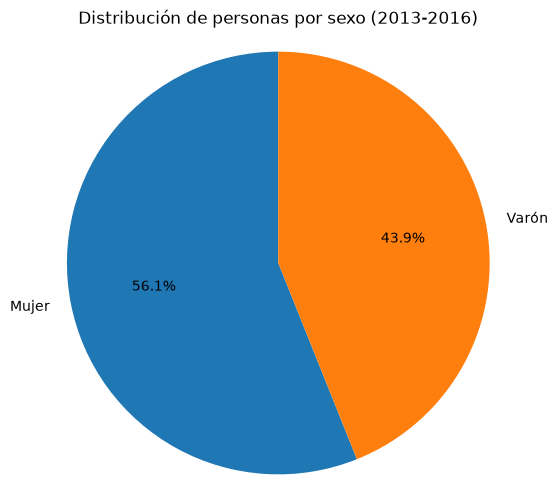

In [13]:
plt.figure(figsize=(6, 6))
sexo_totales = visitas.groupby('sexo', observed=True)['cantidad_personas'].sum()
sexo_totales.index = sexo_totales.index.map({'m': 'Mujer', 'v': 'Varón'})

colors = sns.color_palette('tab10', len(sexo_totales))
plt.pie(sexo_totales.values,
        labels=sexo_totales.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
plt.title('Distribución de personas por sexo (2013-2016)')
plt.axis('equal')
plt.show()

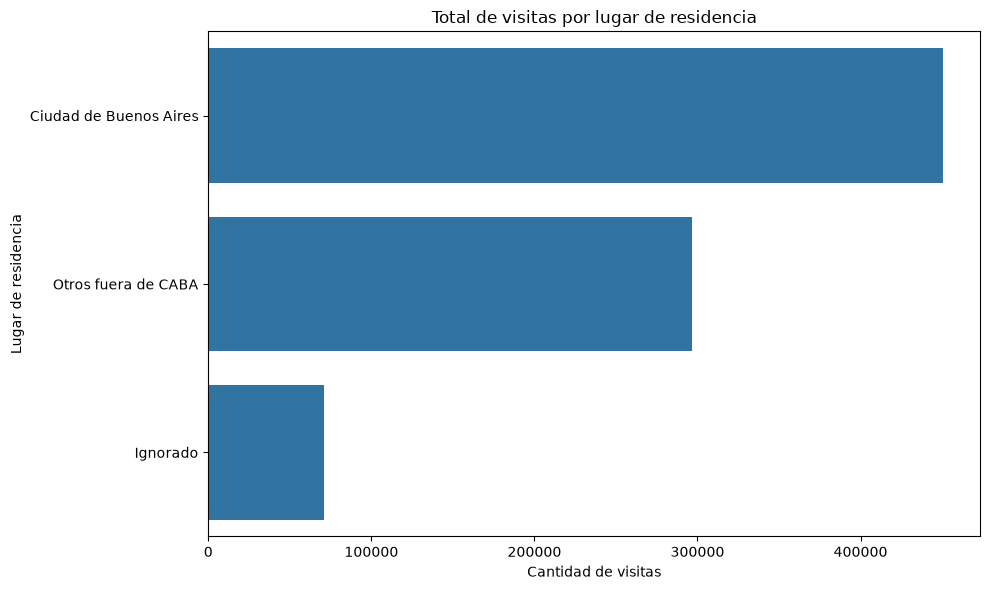

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.barplot(y='lugar_residencia', x='cantidad_personas', data=visitas,
            order=['Ciudad de Buenos Aires', 'Otros fuera de CABA', 'Ignorado'],
            estimator=sum, errorbar=None, ax=ax)
ax.set_title('Total de visitas por lugar de residencia')
ax.set_xlabel('Cantidad de visitas')
ax.set_ylabel('Lugar de residencia')
plt.tight_layout()
plt.show()

#### Entropía (grupo_edad)

In [15]:
# Se calcula la entropía de Shannon para ver qué tan dispersas están las visitas entre grupos etarios
edad_totales = visitas.groupby('grupo_edad', observed=True)['cantidad_personas'].sum()
edad_pi = edad_totales / edad_totales.sum()

# Entropía máxima (si todas las categorías ocurrieran con la misma probabilidad)
H_max = np.log2(visitas['grupo_edad'].nunique())

# Entropía de Shannon con Scipy
H_Shannon = entropy(edad_pi, base=2)

print(f"Entropía H: {H_Shannon:.2f} - Entropía máxima H_max: {H_max:.2f}")

Entropía H: 2.97 - Entropía máxima H_max: 3.46


Resumen de hallazgos: La entropía está relativamente cerca del máximo, lo que indica que las visitas se
reparten entre varios grupos etarios y no se concentran en uno solo (aunque, como se observa en
el gráfico de barras más abajo, sí hay grupos con más participación que otros, especialmente
las personas mayores).

---
### Variable numérica: estadística descriptiva
---

In [16]:
visitas['cantidad_personas'].describe()

count      264.000000
mean      3099.909091
std       3365.310218
min          0.000000
25%        364.500000
50%       1535.500000
75%       6026.250000
max      12809.000000
Name: cantidad_personas, dtype: float64

Nota: Los valores que se brindan en esta descripción corresponden a cada uno de los 264 valores que adoptó
'cantidad_personas', por cada fila/combinación de año, sexo, grupo etario y lugar de residencia. Por este motivo,
se procede a realizar análisis de variables, dado que el análisis de cada una de las 264 observaciones
por separado no permite llegar a conclusiones relevantes.

---
### Relaciones entre variables
---

#### Evolución de las visitas por año y lugar de residencia

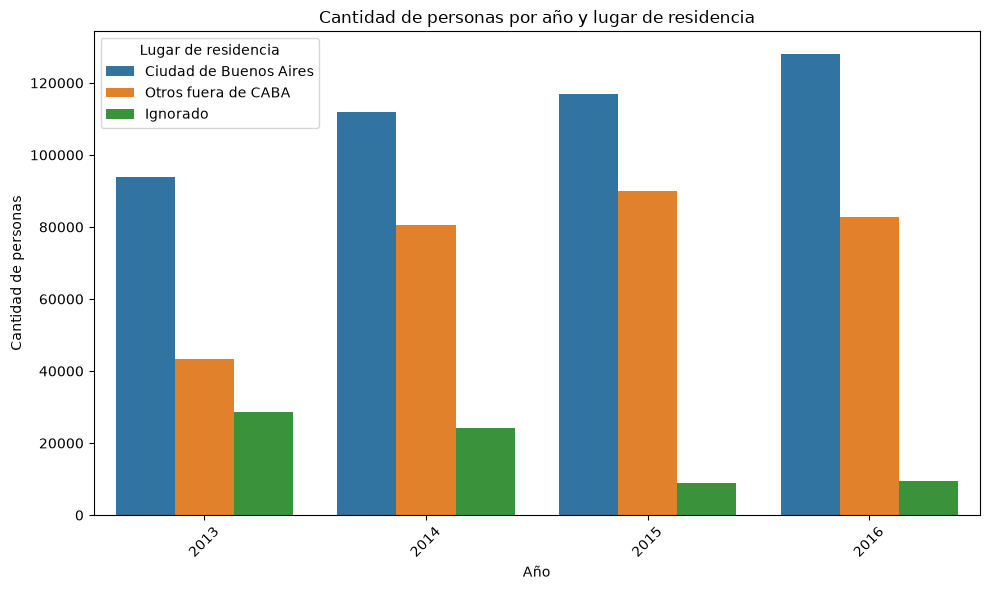

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=visitas,
    x='anio',
    y='cantidad_personas',
    hue='lugar_residencia',
    hue_order=['Ciudad de Buenos Aires', 'Otros fuera de CABA', 'Ignorado'],
    estimator=sum,
    errorbar=None,
    ax=ax
)
ax.set_title('Cantidad de personas por año y lugar de residencia')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de personas')
plt.xticks(rotation=45)
ax.legend(title='Lugar de residencia')
plt.tight_layout()
plt.show()

#### Evolución de las visitas por grupo etario y lugar de residencia

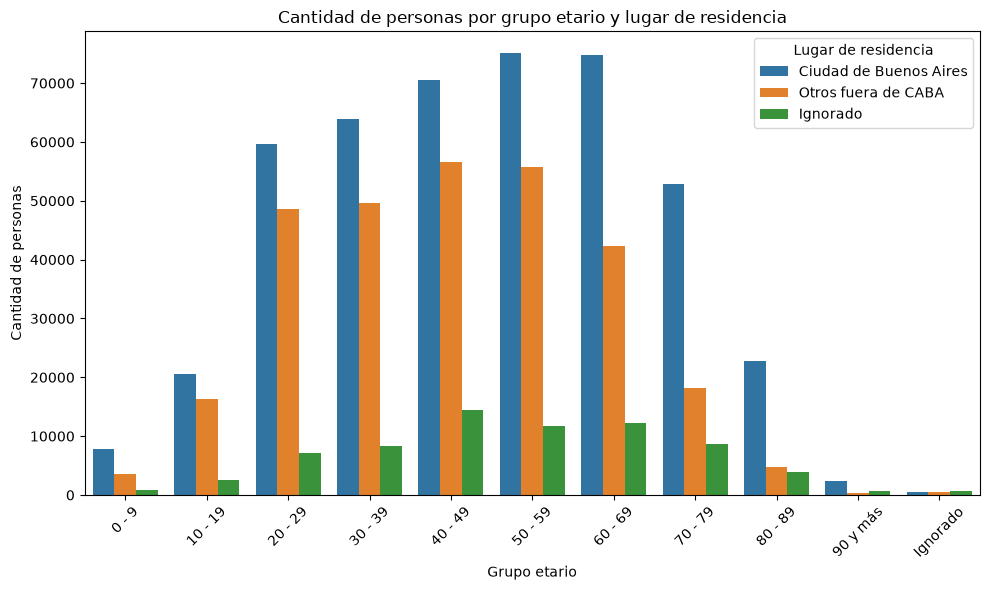

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=visitas,
    x='grupo_edad',
    y='cantidad_personas',
    hue='lugar_residencia',
    hue_order=['Ciudad de Buenos Aires', 'Otros fuera de CABA', 'Ignorado'],
    estimator=sum,
    errorbar=None,
    ax=ax
)
ax.set_title('Cantidad de personas por grupo etario y lugar de residencia')
ax.set_xlabel('Grupo etario')
ax.set_ylabel('Cantidad de personas')
plt.xticks(rotation=45)
ax.legend(title='Lugar de residencia')
plt.tight_layout()
plt.show()

#### Heatmap: Distribución de cantidad de visitas por año y grupo etario

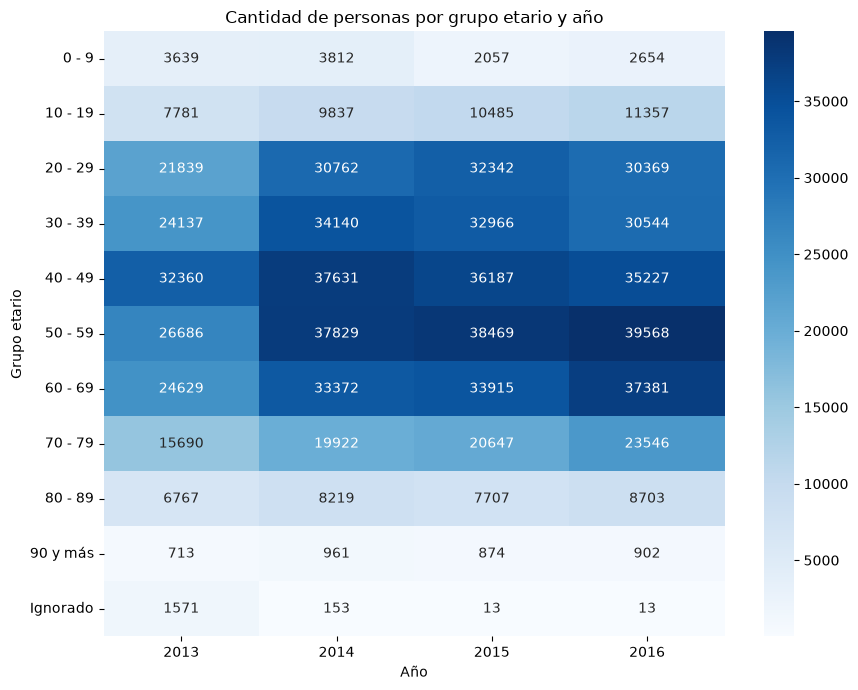

In [19]:
# Se crea la tabla pivote
tabla = visitas.pivot_table(
    index='grupo_edad',
    columns='anio',
    values='cantidad_personas',
    aggfunc='sum',
    observed=False
)

# heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(tabla, cmap='Blues', annot=True, fmt=".0f")

plt.title('Cantidad de personas por grupo etario y año')
plt.xlabel('Año')
plt.ylabel('Grupo etario')
plt.tight_layout()
plt.show()

---
### Conclusiones
---

* El dataset está agregado (no tiene una fila por persona sino por combinación de
  categorías) y no presenta valores faltantes.
* La mayoría de las visitas provienen de personas residentes en la Ciudad de Buenos Aires.
* Hay más visitas registradas de mujeres (`m`) que de varones (`v`) en los cuatro años
  analizados.
* Las visitas aumentan considerablemente entre 2013 y 2016 para ambos sexos, lo que podría
  reflejar tanto un crecimiento real de la concurrencia como una mejora en el registro de
  datos.
* Los grupos etarios con mayor cantidad de visitas son los de mediana edad y adultos
  mayores (40 a 79 años), lo cual es consistente con el objetivo de las Estaciones
  Saludables de promover controles preventivos y actividades para la población adulta.